# Step 1: Understanding the Data (EDA)
## Feature Engineering Series — Deep Dive

This notebook provides a **comprehensive guide to understanding your dataset** before any modeling or feature engineering begins.

We'll use **3 different datasets** to show how EDA looks across different domains:

| Dataset | Domain | Task | Source |
|---------|--------|------|--------|
| **Titanic** | Passenger survival | Binary Classification | `seaborn` |
| **Tips** | Restaurant tipping | Regression | `seaborn` |
| **Iris** | Flower species | Multi-class Classification | `sklearn` |

### What we'll cover:
1. Dataset shape, types, and basic statistics
2. Missing value analysis
3. Distribution analysis (univariate)
4. Correlation analysis (bivariate & multivariate)
5. Target variable analysis
6. Domain context interpretation

---

## 0. Setup — Imports & Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_iris
from scipy import stats

In [4]:
# Plotting style
#plt.rcParams controls resolution (DPI) and default font size.
#sns.set_theme applies a Seaborn style (grid background) and a soft color palette.
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# Load all 3 datasets
titanic  = sns.load_dataset('titanic')
tips     = sns.load_dataset('tips')
iris_raw = load_iris()
iris     = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
iris['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

print(' Datasets loaded:')
print(f'  Titanic : {titanic.shape[0]} rows × {titanic.shape[1]} columns')
print(f'  Tips    : {tips.shape[0]} rows × {tips.shape[1]} columns')
print(f'  Iris    : {iris.shape[0]} rows × {iris.shape[1]} columns')

 Datasets loaded:
  Titanic : 891 rows × 15 columns
  Tips    : 244 rows × 7 columns
  Iris    : 150 rows × 5 columns


---
# Part 1 — Dataset Shape, Types & Basic Statistics

The very first thing: **know what you have**.
- How many rows and columns?
- What are the data types?
- What do basic statistics tell us?

###  Why it matters:
> Different data types require completely different feature engineering strategies. A `float64` column needs scaling; a `category` column needs encoding. Getting this wrong from the start causes silent bugs later.

In [ ]:
# =============================================
# EXAMPLE 1A — Titanic: Shape & Column Types
# =============================================
print('=' * 55)
print('TITANIC DATASET — Shape & Data Types')
print('=' * 55)
#  Used to quickly understand dataset size
print(f'Rows: {titanic.shape[0]}   Columns: {titanic.shape[1]}')
print()

type_summary = pd.DataFrame({
    'dtype'       : titanic.dtypes, # shows data type of each column
    'unique_vals' : titanic.nunique(), # counts unique values in each column
    'sample'      : [titanic[c].dropna().iloc[0] if titanic[c].dropna().shape[0] > 0 else 'N/A'
                     for c in titanic.columns]
})
display(type_summary)

print()
print('Column categories:')
numeric_cols     = titanic.select_dtypes(include='number').columns.tolist()
categorical_cols = titanic.select_dtypes(include=['object','category','bool']).columns.tolist()
print(f'  Numeric     : {numeric_cols}')
print(f'  Categorical : {categorical_cols}')

TITANIC DATASET — Shape & Data Types
Rows: 891   Columns: 15



,dtype,unique_vals,sample
survived,int64,2,0
pclass,int64,3,3
sex,str,2,male
age,float64,88,22.0
sibsp,int64,7,1
parch,int64,7,0
fare,float64,248,7.25
embarked,str,3,S
class,category,3,Third
who,str,3,man



Column categories:
  Numeric     : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
  Categorical : ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [8]:
# =============================================
# EXAMPLE 1B — Titanic: Descriptive Statistics
# =============================================
#  Used to quickly understand numeric distributions and categorical value counts
display(titanic.describe().round(2))

print('\nCategorical columns — value counts summary:')
for col in ['sex', 'embarked', 'class', 'who']:
    print(f'\n  {col}:')
    vc = titanic[col].value_counts()
    for k, v in vc.items():
        pct = v / len(titanic) * 100
        print(f'    {str(k):<12} {v:>4}  ({pct:.1f}%)')

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33



Categorical columns — value counts summary:

  sex:
    male          577  (64.8%)
    female        314  (35.2%)

  embarked:
    S             644  (72.3%)
    C             168  (18.9%)
    Q              77  (8.6%)

  class:
    Third         491  (55.1%)
    First         216  (24.2%)
    Second        184  (20.7%)

  who:
    man           537  (60.3%)
    woman         271  (30.4%)
    child          83  (9.3%)


In [9]:
# =============================================
# EXAMPLE 1C — Tips: Descriptive Statistics
# =============================================
print('=' * 55)
print('TIPS DATASET — Shape & Basic Statistics')
print('=' * 55)
print(f'Rows: {tips.shape[0]}   Columns: {tips.shape[1]}')
print()
display(tips.head())
print()
display(tips.describe().round(2))

print('\n💡 Domain note: tip_pct would be more meaningful than raw tip amount')
tips['tip_pct'] = tips['tip'] / tips['total_bill'] * 100
print(f'   Tip percentage stats: mean={tips["tip_pct"].mean():.1f}%, '
      f'min={tips["tip_pct"].min():.1f}%, max={tips["tip_pct"].max():.1f}%')

TIPS DATASET — Shape & Basic Statistics
Rows: 244   Columns: 7



,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00



💡 Domain note: tip_pct would be more meaningful than raw tip amount
   Tip percentage stats: mean=16.1%, min=3.6%, max=71.0%


In [ ]:
# =============================================
# EXAMPLE 1D — Iris: Descriptive Statistics
# =============================================
print('=' * 55)
print('IRIS DATASET — Shape & Basic Statistics')
print('=' * 55)
display(iris.describe().round(3))

print('\nClass balance:')
#  Used to check if classes are balanced or imbalanced (important for classification tasks)
print(iris['species'].value_counts())
print('\nPerfectly balanced — 50 samples per class')

IRIS DATASET — Shape & Basic Statistics


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500



Class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Perfectly balanced — 50 samples per class


---
#  Part 2 — Missing Value Analysis

Missing data is one of the most common real-world problems. Before fixing it, **understand it**:
- How much data is missing?
- Which columns?
- Is missingness *random* or *informative*?

###  Three types of missingness:
| Type | Meaning | Example |
|------|---------|--------|
| **MCAR** | Missing Completely At Random | Sensor glitch |
| **MAR** | Missing At Random (depends on other columns) | Age not recorded for children |
| **MNAR** | Missing Not At Random (depends on value itself) | High earners skip income field |

In [ ]:
# =============================================
# EXAMPLE 2A — Titanic: Missing Value Audit
# =============================================
#  Used to identify which columns have missing values and how much is missing
def missing_report(df, name):
    missing = pd.DataFrame({
        'count'  : df.isnull().sum(),
        'pct'    : (df.isnull().sum() / len(df) * 100).round(1),
        'dtype'  : df.dtypes
    })
    missing = missing[missing['count'] > 0].sort_values('pct', ascending=False)
    print(f'Missing values in {name}:')
    if len(missing) == 0:
        print('  None — dataset is complete!')
    else:
        display(missing)
    return missing

m_titanic = missing_report(titanic, 'Titanic')
print()
m_tips    = missing_report(tips, 'Tips')
print()
m_iris    = missing_report(iris, 'Iris')

Missing values in Titanic:


,count,pct,dtype
deck,688,77.2,category
age,177,19.9,float64
embarked,2,0.2,str
embark_town,2,0.2,str



Missing values in Tips:
  None — dataset is complete!

Missing values in Iris:
  None — dataset is complete!


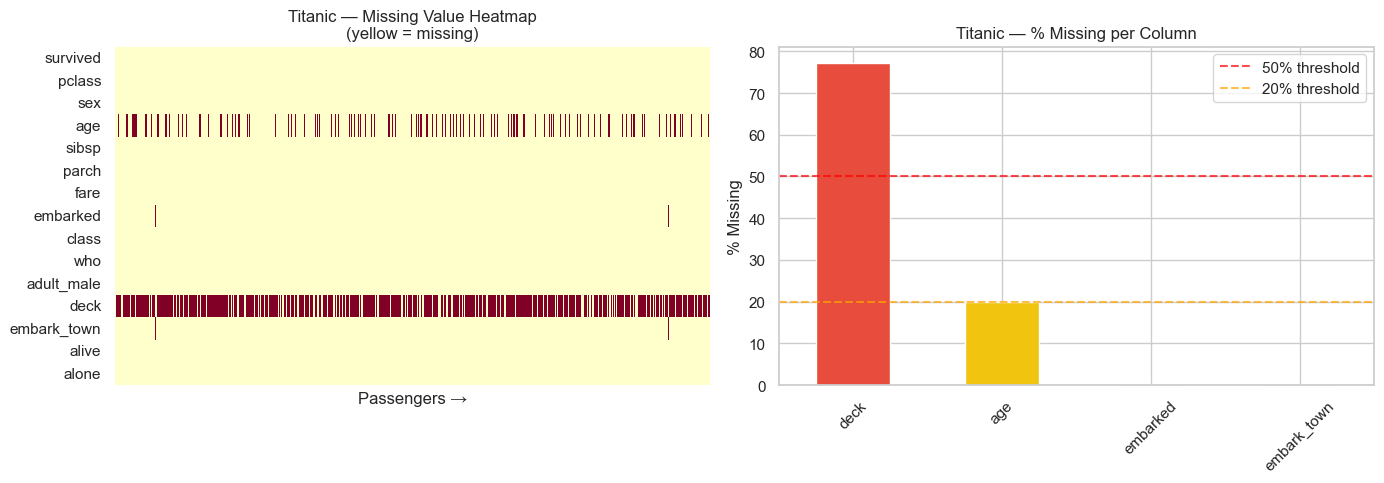

Interpretation:
  - deck (77% missing) → likely should be dropped
  - age (20% missing)  → impute (informative column)
  - embarked (<1%)     → safe to impute with mode


In [ ]:
# =============================================
# EXAMPLE 2B — Missing Value Heatmap & Bar Chart
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap — pattern of missingness
missing_matrix = titanic.isnull().astype(int)
#cbar=False → hides color legend (cleaner view)
sns.heatmap(missing_matrix.T, cmap='YlOrRd', cbar=False,
            yticklabels=titanic.columns, xticklabels=False, ax=axes[0])
axes[0].set_title('Titanic — Missing Value Heatmap\n(yellow = missing)', fontsize=12)
axes[0].set_xlabel('Passengers →')

# Bar chart of % missing
pct_missing = (titanic.isnull().sum() / len(titanic) * 100).sort_values(ascending=False)
pct_missing = pct_missing[pct_missing > 0]
colors = ('#e74c3c' if p > 50 else '#e67e22' if p > 20 else '#f1c40f' for p in pct_missing)
pct_missing.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].axhline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
axes[1].axhline(20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
axes[1].set_title('Titanic — % Missing per Column', fontsize=12)
axes[1].set_ylabel('% Missing')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('Interpretation:')
print('  - deck (77% missing) → likely should be dropped')
print('  - age (20% missing)  → impute (informative column)')
print('  - embarked (<1%)     → safe to impute with mode')

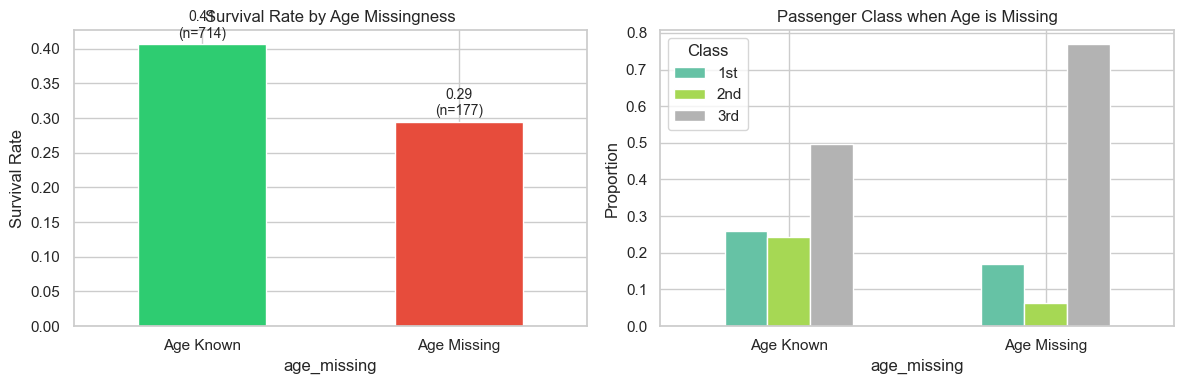

🔍 Finding: Passengers with missing age have a LOWER survival rate.
   This suggests missingness is NOT random (MAR/MNAR).
   → Add age_missing as a binary feature — it carries information!


In [15]:
# =============================================
# EXAMPLE 2C — Is Missingness Informative?
# Test: does missing age correlate with survival?
# =============================================
titanic['age_missing'] = titanic['age'].isnull().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival rate by age missingness
surv_by_missing = titanic.groupby('age_missing')['survived'].agg(['mean','count'])
surv_by_missing['mean'].plot(kind='bar', ax=axes[0],
                              color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_xticklabels(['Age Known', 'Age Missing'], rotation=0)
axes[0].set_title('Survival Rate by Age Missingness', fontsize=12)
axes[0].set_ylabel('Survival Rate')
for i, (_, row) in enumerate(surv_by_missing.iterrows()):
    axes[0].text(i, row['mean'] + 0.01, f"{row['mean']:.2f}\n(n={int(row['count'])})",
                 ha='center', fontsize=10)

# Class distribution by age missingness
pd.crosstab(titanic['age_missing'], titanic['pclass'],
            normalize='index').plot(kind='bar', ax=axes[1], colormap='Set2',
                                    edgecolor='white')
axes[1].set_xticklabels(['Age Known', 'Age Missing'], rotation=0)
axes[1].set_title('Passenger Class when Age is Missing', fontsize=12)
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Class', labels=['1st','2nd','3rd'])

plt.tight_layout()
plt.show()

print('🔍 Finding: Passengers with missing age have a LOWER survival rate.')
print('   This suggests missingness is NOT random (MAR/MNAR).')
print('   → Add age_missing as a binary feature — it carries information!')

---
# Part 3 — Distribution Analysis (Univariate)
Understanding each feature **on its own**:
- Is it normally distributed? Skewed? Bimodal?
- Are there outliers?
- What range of values exist?

### Why it matters:
> Many ML models assume Gaussian input. Knowing the distribution tells you *which transformations* to apply and *which models* will work well.

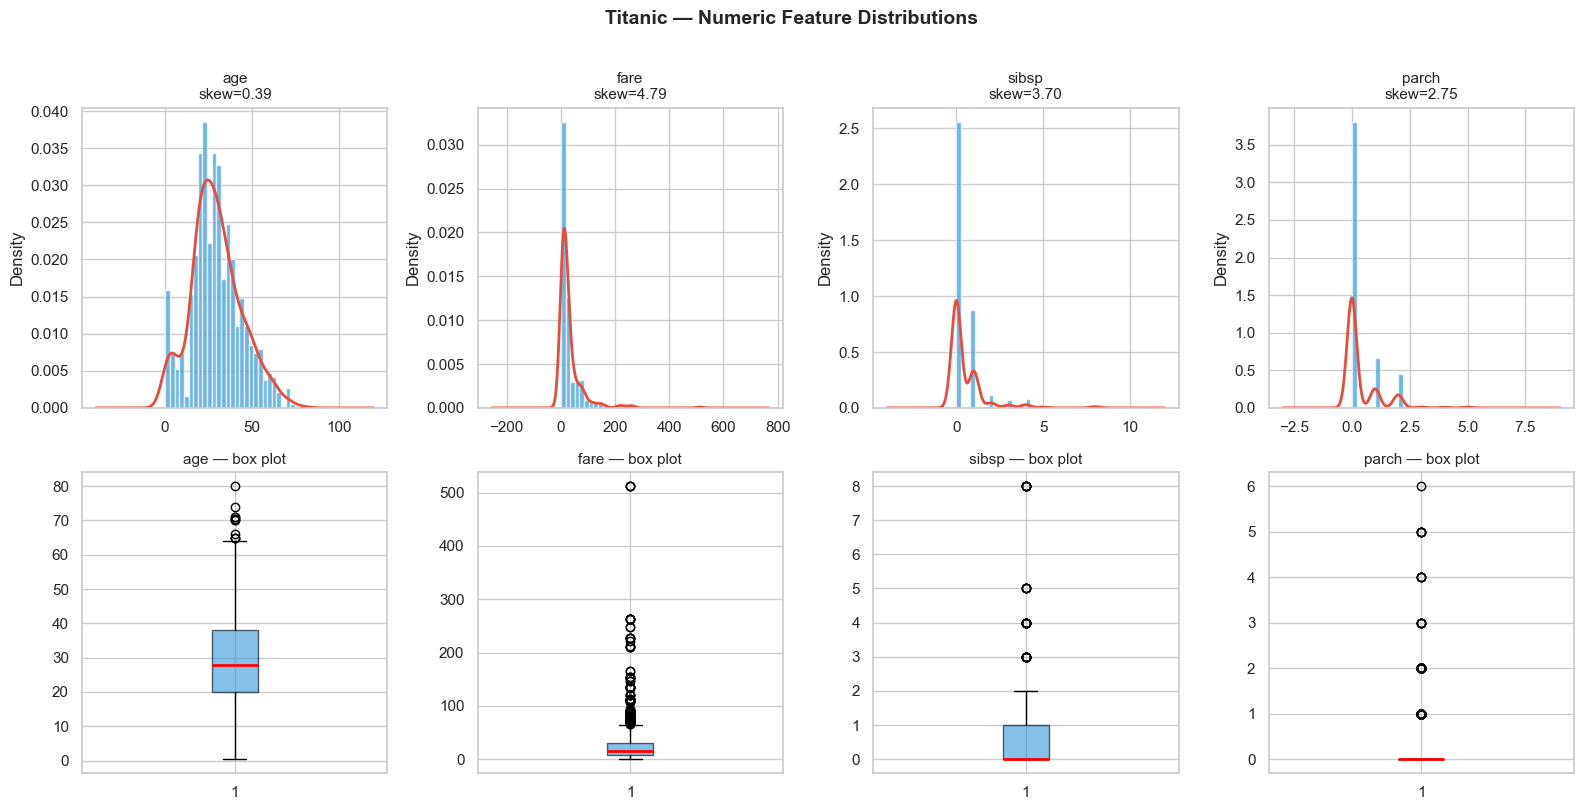

Skewness interpretation:
  age      skew=  0.39  (approx. normal)
  fare     skew=  4.79  (highly right-skewed)
  sibsp    skew=  3.70  (highly right-skewed)
  parch    skew=  2.75  (highly right-skewed)


In [16]:
# =============================================
# EXAMPLE 3A — Titanic: Numeric Distributions
# =============================================
numeric_feats = ['age', 'fare', 'sibsp', 'parch']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, col in enumerate(numeric_feats):
    data = titanic[col].dropna()

    # Histogram + KDE
    axes[0, i].hist(data, bins=30, color='#3498db', edgecolor='white', density=True, alpha=0.7)
    data.plot.kde(ax=axes[0, i], color='#e74c3c', linewidth=2)
    axes[0, i].set_title(f'{col}\nskew={data.skew():.2f}', fontsize=11)
    axes[0, i].set_ylabel('Density')

    # Box plot
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                        boxprops=dict(facecolor='#3498db', alpha=0.6),
                        medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} — box plot', fontsize=11)

plt.suptitle('Titanic — Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Skewness interpretation:')
for col in numeric_feats:
    sk = titanic[col].skew()
    tag = '(highly right-skewed)' if sk > 1 else '(moderately skewed)' if sk > 0.5 else '(approx. normal)'
    print(f'  {col:<8} skew={sk:>6.2f}  {tag}')

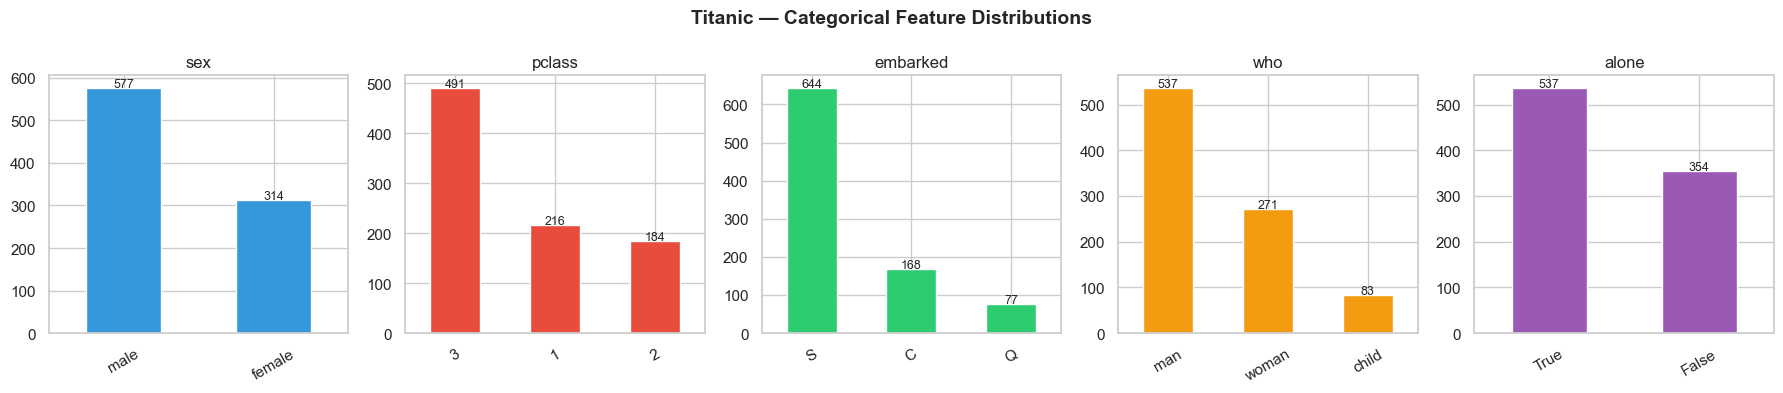

Observations:
  - More males than females (class imbalance in sex)
  - More 3rd class passengers (socioeconomic distribution)
  - Southampton was most common boarding point


In [17]:
# =============================================
# EXAMPLE 3B — Titanic: Categorical Distributions
# =============================================
cat_feats = ['sex', 'pclass', 'embarked', 'who', 'alone']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for i, col in enumerate(cat_feats):
    vc = titanic[col].value_counts()
    vc.plot(kind='bar', ax=axes[i], color=colors[i], edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    # Add count labels
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)

plt.suptitle('Titanic — Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observations:')
print('  - More males than females (class imbalance in sex)')
print('  - More 3rd class passengers (socioeconomic distribution)')
print('  - Southampton was most common boarding point')

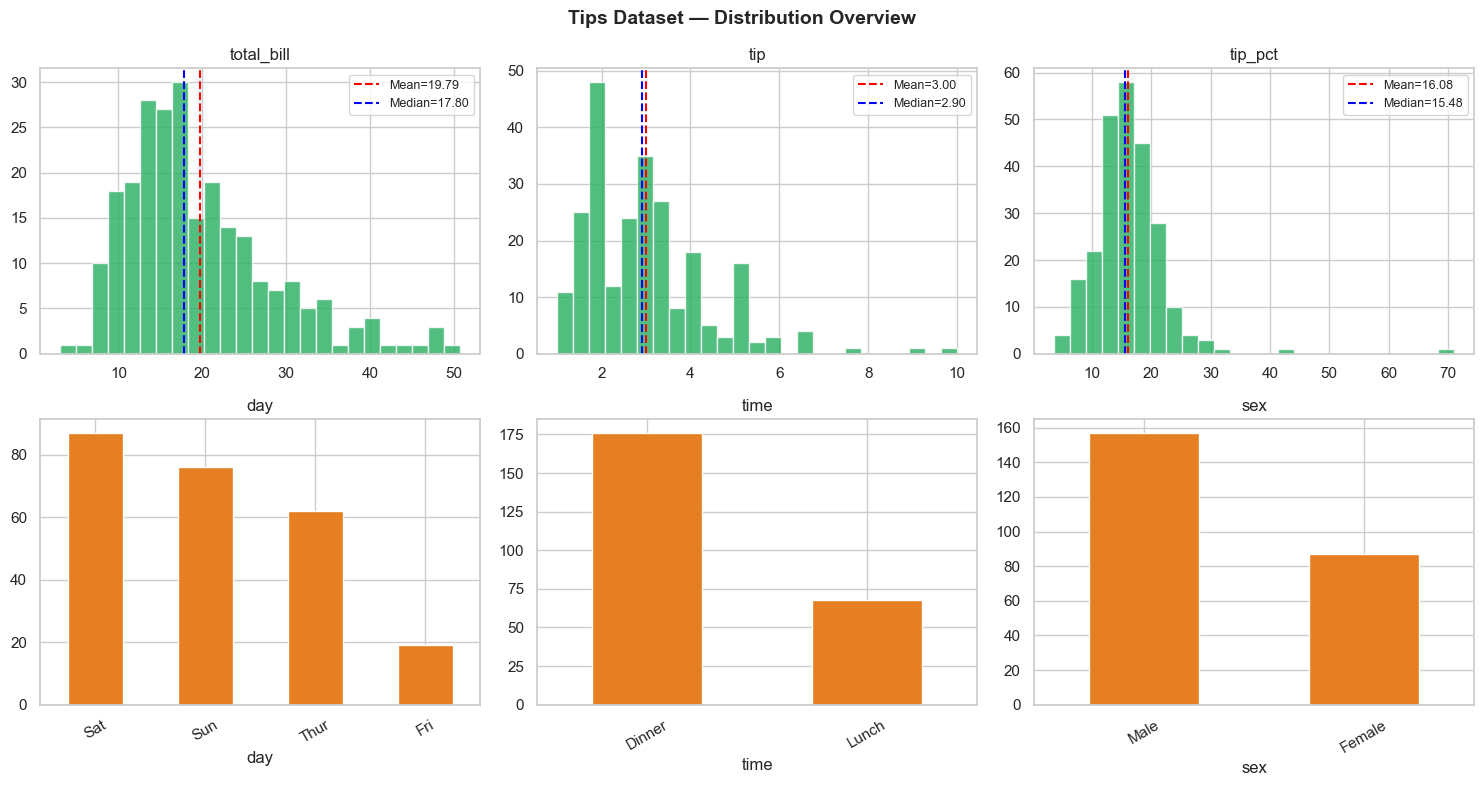

Domain observations:
  - total_bill and tip are right-skewed (common in monetary data)
  - tip_pct is more normally distributed → better target for regression
  - Most data collected on Sat/Sun (weekend dining)


In [18]:
# =============================================
# EXAMPLE 3C — Tips Dataset: Full Distribution Overview
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Numeric features
for i, col in enumerate(['total_bill', 'tip', 'tip_pct']):
    data = tips[col]
    axes[0, i].hist(data, bins=25, color='#27ae60', edgecolor='white', alpha=0.8)
    axes[0, i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean={data.mean():.2f}')
    axes[0, i].axvline(data.median(), color='blue', linestyle='--', label=f'Median={data.median():.2f}')
    axes[0, i].set_title(f'{col}', fontsize=12)
    axes[0, i].legend(fontsize=9)

# Categorical features
for i, col in enumerate(['day', 'time', 'sex']):
    vc = tips[col].value_counts()
    vc.plot(kind='bar', ax=axes[1, i], color='#e67e22', edgecolor='white')
    axes[1, i].set_title(col, fontsize=12)
    axes[1, i].tick_params(axis='x', rotation=30)

plt.suptitle('Tips Dataset — Distribution Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Domain observations:')
print('  - total_bill and tip are right-skewed (common in monetary data)')
print('  - tip_pct is more normally distributed → better target for regression')
print('  - Most data collected on Sat/Sun (weekend dining)')

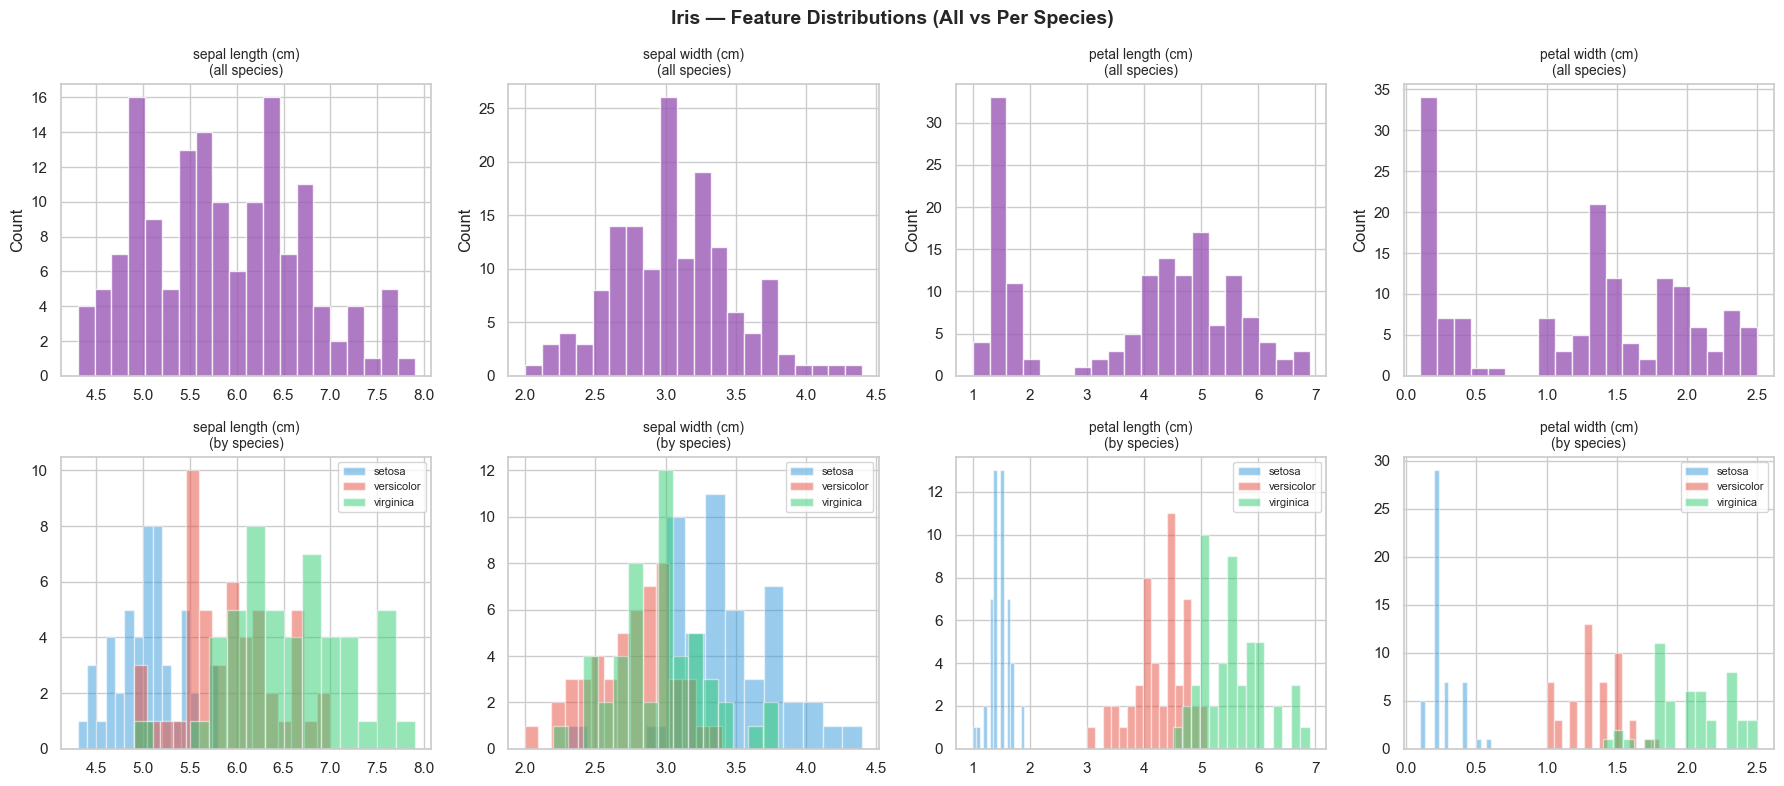

Key insight:
  - Sepal width looks bimodal overall, but each species is unimodal
  - Petal features clearly separate species → high discriminative power
  - This is why stratified EDA (by target class) is essential!


In [19]:
# =============================================
# EXAMPLE 3D — Iris: Distribution per Species
# (Stratified univariate analysis)
# =============================================
feature_cols = ['sepal length (cm)', 'sepal width (cm)',
                'petal length (cm)', 'petal width (cm)']
species_colors = {'setosa': '#3498db', 'versicolor': '#e74c3c', 'virginica': '#2ecc71'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, feat in enumerate(feature_cols):
    # Overall distribution
    axes[0, i].hist(iris[feat], bins=20, color='#9b59b6', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{feat}\n(all species)', fontsize=10)
    axes[0, i].set_ylabel('Count')

    # Per-species overlay
    for sp, col in species_colors.items():
        data = iris[iris['species'] == sp][feat]
        axes[1, i].hist(data, bins=15, alpha=0.5, color=col, label=sp, edgecolor='white')
    axes[1, i].set_title(f'{feat}\n(by species)', fontsize=10)
    axes[1, i].legend(fontsize=8)

plt.suptitle('Iris — Feature Distributions (All vs Per Species)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key insight:')
print('  - Sepal width looks bimodal overall, but each species is unimodal')
print('  - Petal features clearly separate species → high discriminative power')
print('  - This is why stratified EDA (by target class) is essential!')

---
#  Part 4 — Correlation Analysis (Bivariate & Multivariate)

Now we look at **relationships between features**:
- Which features move together (positive correlation)?
- Which features are inversely related?
- Are there redundant features we can drop?

###  Why it matters:
> Highly correlated features add redundancy and can cause multicollinearity in linear models. Knowing correlations upfront lets you prune the feature space intelligently.

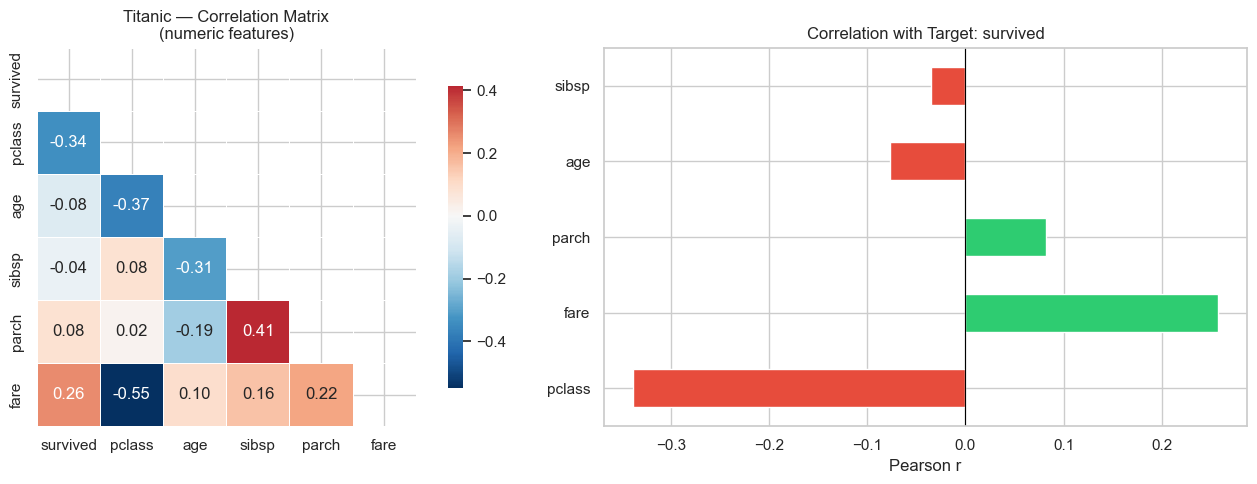

Top correlations with survival:
  pclass       r=-0.338  ↓ negative
  fare         r= 0.257  ↑ positive
  parch        r= 0.082  ↑ positive
  age          r=-0.077  ↓ negative
  sibsp        r=-0.035  ↓ negative


In [20]:
# =============================================
# EXAMPLE 4A — Titanic: Correlation Heatmap
# =============================================
num_titanic = titanic.select_dtypes(include='number').drop(columns=['age_missing'], errors='ignore')
corr_matrix = num_titanic.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=axes[0], linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Titanic — Correlation Matrix\n(numeric features)', fontsize=12)

# Correlation with target (survived)
target_corr = corr_matrix['survived'].drop('survived').sort_values(key=abs, ascending=False)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr]
target_corr.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Target: survived', fontsize=12)
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

print('Top correlations with survival:')
for feat, val in target_corr.items():
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f'  {feat:<12} r={val:>6.3f}  {direction}')

Tips — Pairwise Scatter Plots (colored by time of day)


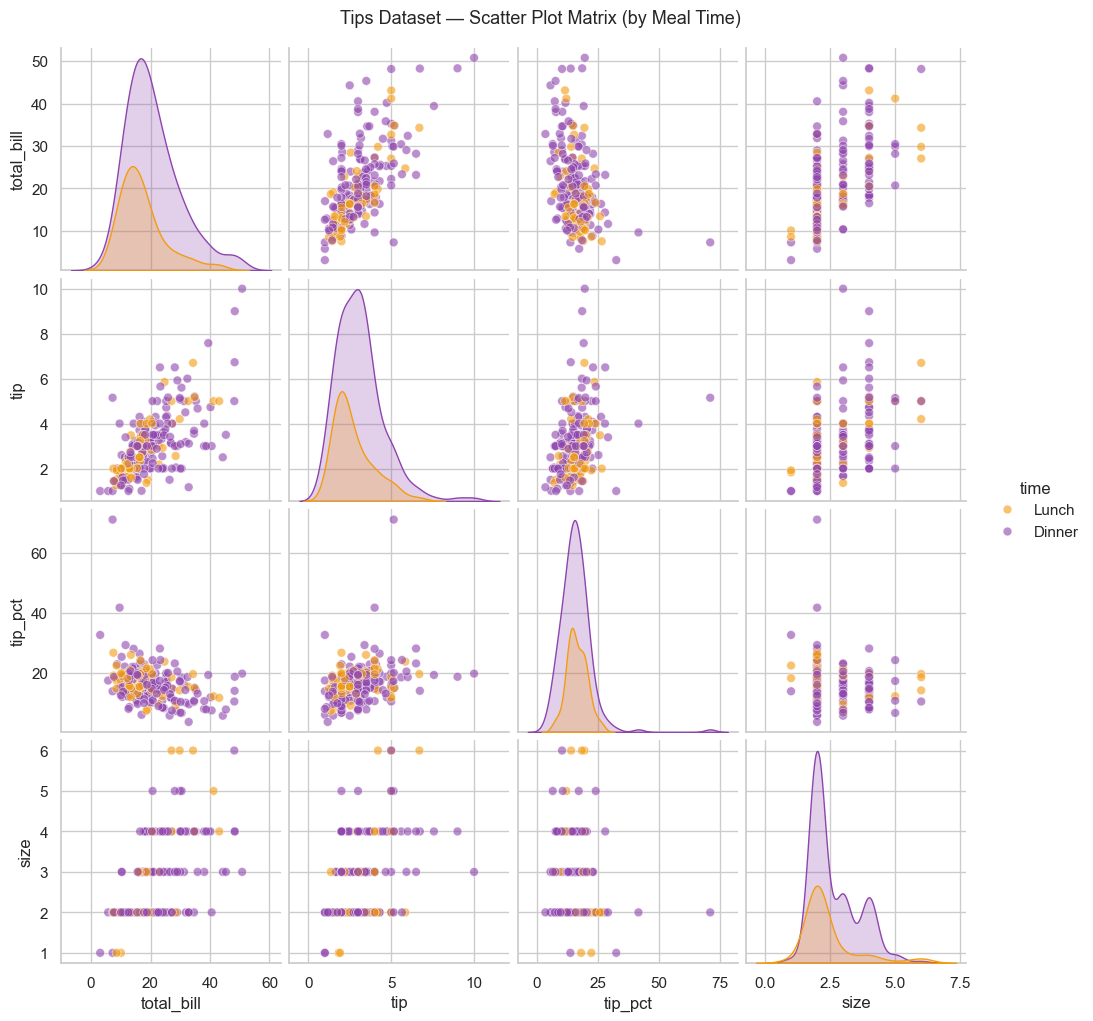

Observations:
  - total_bill and tip are strongly correlated (r ≈ 0.68)
  - tip_pct and total_bill are weakly correlated → tip_pct is more independent
  - Dinner bills tend to be higher than lunch bills


In [21]:
# =============================================
# EXAMPLE 4B — Tips: Scatter Plot Matrix
# =============================================
print('Tips — Pairwise Scatter Plots (colored by time of day)')
g = sns.pairplot(tips[['total_bill', 'tip', 'tip_pct', 'size', 'time']],
                  hue='time', palette={'Lunch': '#f39c12', 'Dinner': '#8e44ad'},
                  diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40})
g.fig.suptitle('Tips Dataset — Scatter Plot Matrix (by Meal Time)', y=1.02, fontsize=13)
plt.show()

print('Observations:')
print('  - total_bill and tip are strongly correlated (r ≈ 0.68)')
print('  - tip_pct and total_bill are weakly correlated → tip_pct is more independent')
print('  - Dinner bills tend to be higher than lunch bills')

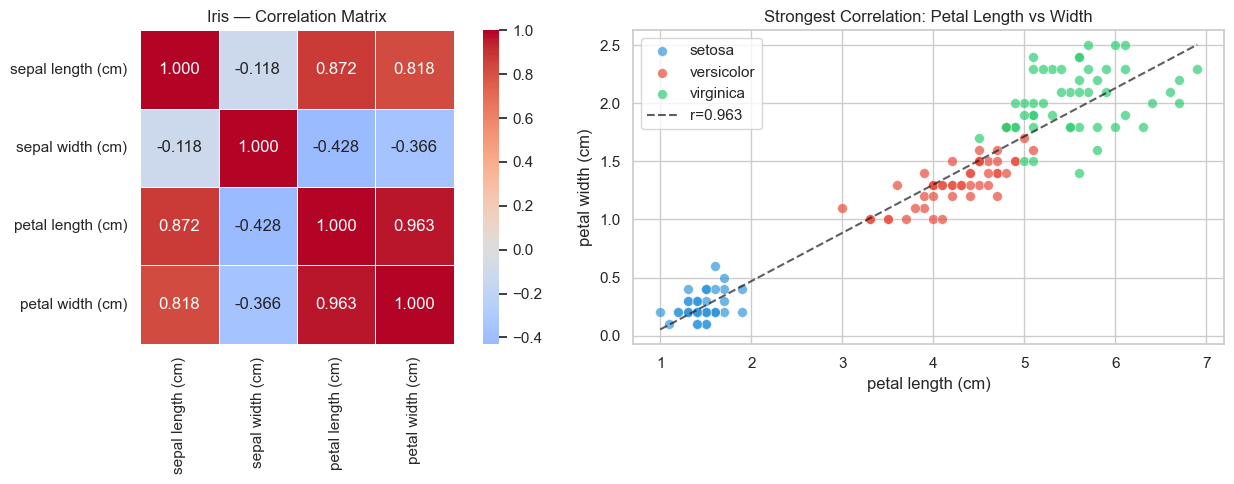

Petal length vs petal width: r = 0.9629
 High multicollinearity between petal features (r=0.96)
   → Consider using only one, or applying PCA


In [30]:
# =============================================
# EXAMPLE 4C — Iris: Correlation + Scatter Matrix
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iris_corr = iris[feature_cols].corr()
sns.heatmap(iris_corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Iris — Correlation Matrix', fontsize=12)

# Scatter: most correlated pair
for sp, col in species_colors.items():
    subset = iris[iris['species'] == sp]
    axes[1].scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                    c=col, label=sp, alpha=0.7, s=50, edgecolors='white', linewidths=0.5)

# Add regression line
slope, intercept, r, p, _ = stats.linregress(iris['petal length (cm)'], iris['petal width (cm)'])
x_line = np.linspace(iris['petal length (cm)'].min(), iris['petal length (cm)'].max(), 100)
axes[1].plot(x_line, slope * x_line + intercept, 'k--', alpha=0.7, label=f'r={r:.3f}')
axes[1].set_xlabel('petal length (cm)')
axes[1].set_ylabel('petal width (cm)')
axes[1].set_title('Strongest Correlation: Petal Length vs Width', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Petal length vs petal width: r = {r:.4f}')
print(' High multicollinearity between petal features (r=0.96)')
print('   → Consider using only one, or applying PCA')

---
#  Part 5 — Target Variable Analysis

The most important step: understand what you're trying to predict.
- Is the target balanced (classification) or skewed (regression)?
- How does each feature relate to the target?

###  Why it matters:
> If the target is heavily imbalanced (e.g., 99% negative class), accuracy becomes a misleading metric. The target distribution shapes your entire modeling strategy.

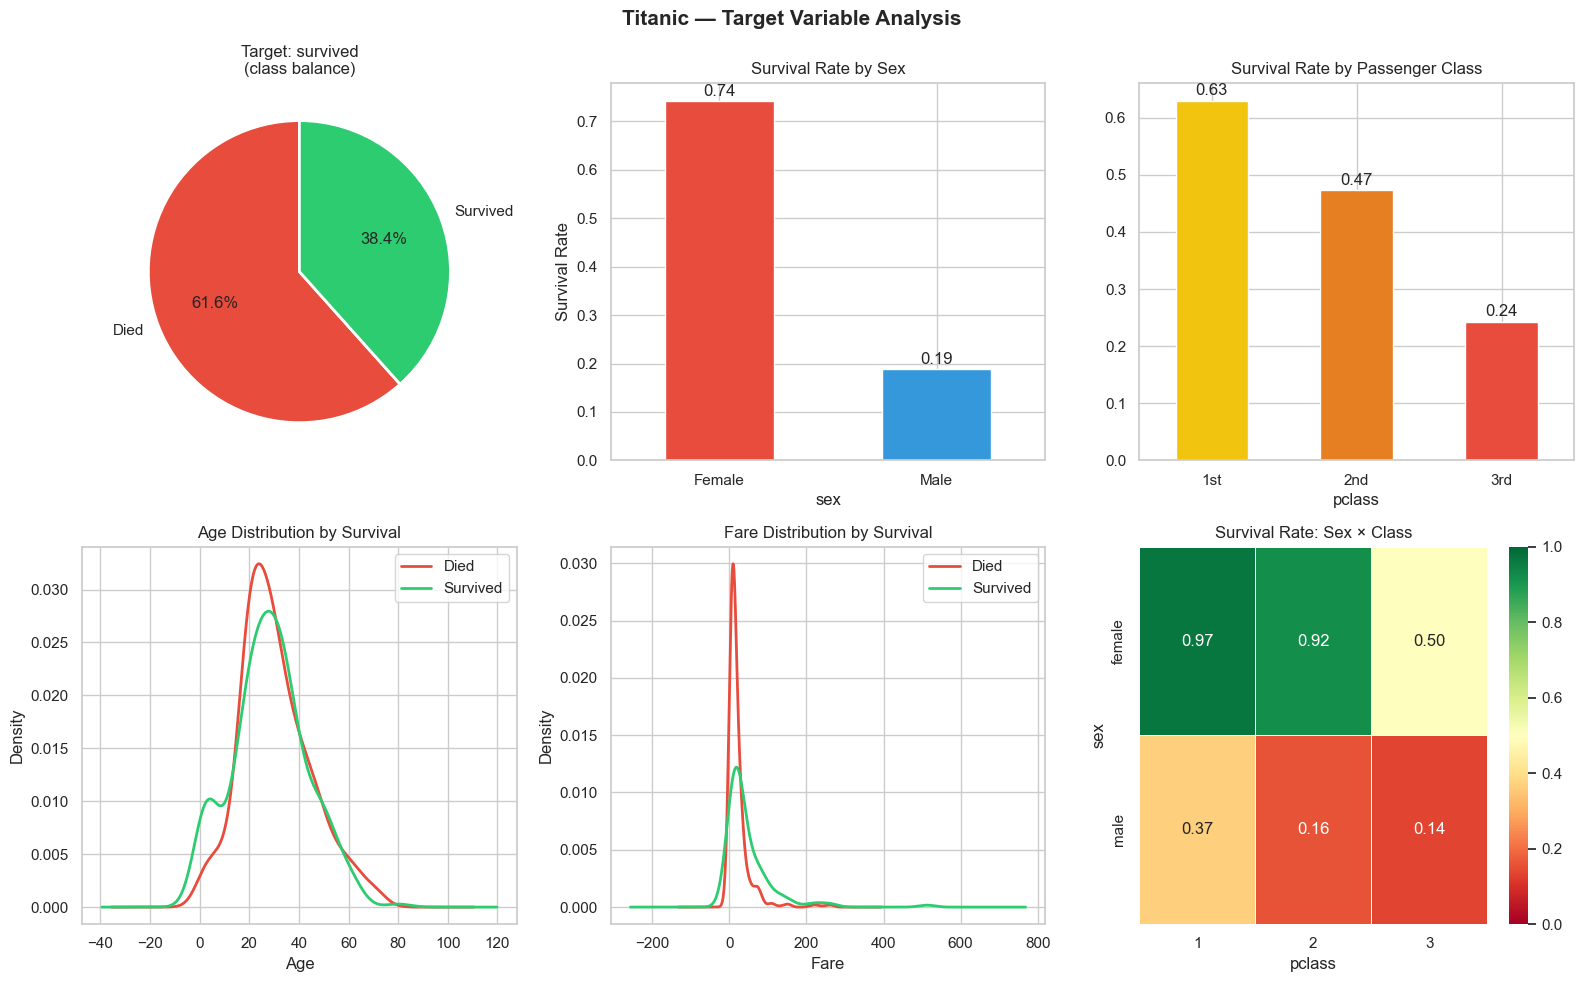

Key findings:
  - 62% died vs 38% survived — moderate class imbalance
  - Women survived at 74%, men only at 19% → strongest predictor
  - 1st class survived at 63%, 3rd class at only 24%
  - Younger passengers had slightly better survival rates


In [23]:
# =============================================
# EXAMPLE 5A — Titanic: Binary Classification Target
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Target distribution
vc = titanic['survived'].value_counts()
axes[0, 0].pie(vc.values, labels=['Died','Survived'], autopct='%1.1f%%',
                colors=['#e74c3c', '#2ecc71'], startangle=90,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 0].set_title('Target: survived\n(class balance)', fontsize=12)

# Survival by sex
surv_sex = titanic.groupby('sex')['survived'].mean()
surv_sex.plot(kind='bar', ax=axes[0, 1], color=['#e74c3c','#3498db'], edgecolor='white', width=0.5)
axes[0, 1].set_title('Survival Rate by Sex', fontsize=12)
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].set_xticklabels(['Female', 'Male'], rotation=0)
for i, v in enumerate(surv_sex): axes[0, 1].text(i, v+0.01, f'{v:.2f}', ha='center')

# Survival by class
surv_class = titanic.groupby('pclass')['survived'].mean()
surv_class.plot(kind='bar', ax=axes[0, 2], color=['#f1c40f','#e67e22','#e74c3c'],
                edgecolor='white', width=0.5)
axes[0, 2].set_title('Survival Rate by Passenger Class', fontsize=12)
axes[0, 2].set_xticklabels(['1st','2nd','3rd'], rotation=0)
for i, v in enumerate(surv_class): axes[0, 2].text(i, v+0.01, f'{v:.2f}', ha='center')

# Age distribution by survival
titanic[titanic['survived']==0]['age'].dropna().plot(kind='kde', ax=axes[1, 0],
    color='#e74c3c', label='Died', linewidth=2)
titanic[titanic['survived']==1]['age'].dropna().plot(kind='kde', ax=axes[1, 0],
    color='#2ecc71', label='Survived', linewidth=2)
axes[1, 0].set_title('Age Distribution by Survival', fontsize=12)
axes[1, 0].legend()
axes[1, 0].set_xlabel('Age')

# Fare distribution by survival
titanic[titanic['survived']==0]['fare'].plot(kind='kde', ax=axes[1, 1],
    color='#e74c3c', label='Died', linewidth=2)
titanic[titanic['survived']==1]['fare'].plot(kind='kde', ax=axes[1, 1],
    color='#2ecc71', label='Survived', linewidth=2)
axes[1, 1].set_title('Fare Distribution by Survival', fontsize=12)
axes[1, 1].legend()
axes[1, 1].set_xlabel('Fare')

# Heatmap: survival rate by sex × class
pivot = titanic.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1, 2],
            linewidths=0.5, vmin=0, vmax=1)
axes[1, 2].set_title('Survival Rate: Sex × Class', fontsize=12)

plt.suptitle('Titanic — Target Variable Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key findings:')
print('  - 62% died vs 38% survived — moderate class imbalance')
print('  - Women survived at 74%, men only at 19% → strongest predictor')
print('  - 1st class survived at 63%, 3rd class at only 24%')
print('  - Younger passengers had slightly better survival rates')

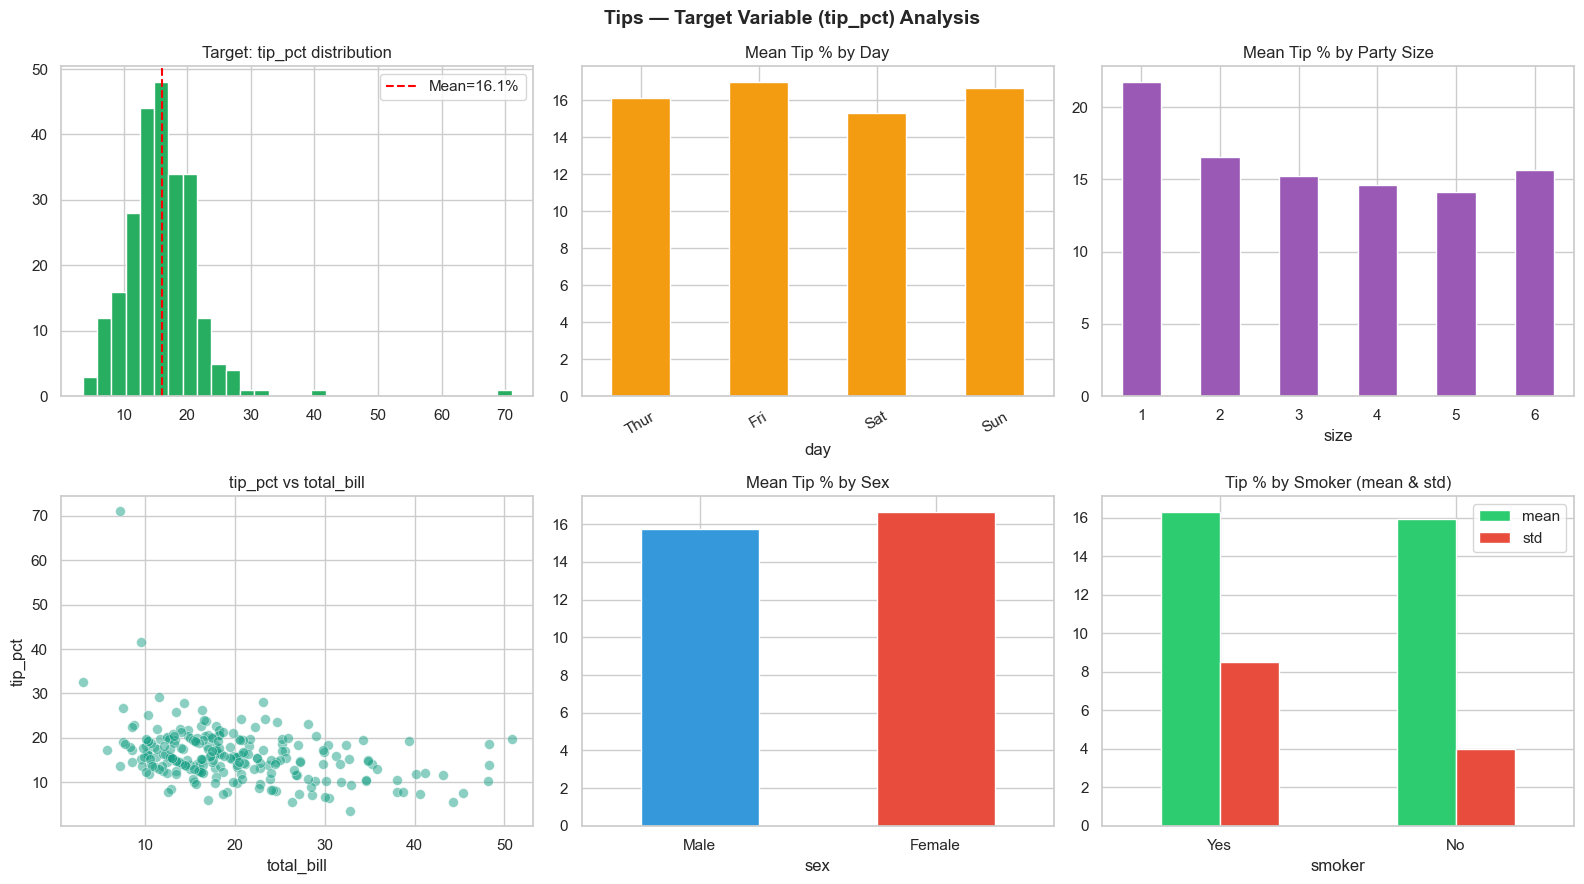

Key findings:
  - Tip % is fairly normally distributed around ~16%
  - Larger parties tip a slightly lower percentage
  - Friday shows highest average tip (but small sample)


In [24]:
# =============================================
# EXAMPLE 5B — Tips: Regression Target Analysis
# =============================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Target: tip_pct distribution
axes[0, 0].hist(tips['tip_pct'], bins=30, color='#27ae60', edgecolor='white')
axes[0, 0].axvline(tips['tip_pct'].mean(), color='red', linestyle='--',
                    label=f"Mean={tips['tip_pct'].mean():.1f}%")
axes[0, 0].set_title('Target: tip_pct distribution', fontsize=12)
axes[0, 0].legend()

# Tip % by day
tips.groupby('day')['tip_pct'].mean().reindex(['Thur','Fri','Sat','Sun']).plot(
    kind='bar', ax=axes[0, 1], color='#f39c12', edgecolor='white')
axes[0, 1].set_title('Mean Tip % by Day', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=30)

# Tip % by meal size
tips.groupby('size')['tip_pct'].mean().plot(
    kind='bar', ax=axes[0, 2], color='#9b59b6', edgecolor='white')
axes[0, 2].set_title('Mean Tip % by Party Size', fontsize=12)
axes[0, 2].tick_params(axis='x', rotation=0)

# tip_pct vs total_bill
axes[1, 0].scatter(tips['total_bill'], tips['tip_pct'], alpha=0.5,
                    color='#16a085', edgecolors='white', linewidths=0.5, s=50)
axes[1, 0].set_xlabel('total_bill')
axes[1, 0].set_ylabel('tip_pct')
axes[1, 0].set_title('tip_pct vs total_bill', fontsize=12)

# Tip % by sex
tips.groupby('sex')['tip_pct'].mean().plot(
    kind='bar', ax=axes[1, 1], color=['#3498db','#e74c3c'], edgecolor='white', width=0.5)
axes[1, 1].set_title('Mean Tip % by Sex', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=0)

# Tip % by smoker
tips.groupby('smoker')['tip_pct'].agg(['mean','std']).plot(
    kind='bar', ax=axes[1, 2], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1, 2].set_title('Tip % by Smoker (mean & std)', fontsize=12)
axes[1, 2].tick_params(axis='x', rotation=0)

plt.suptitle('Tips — Target Variable (tip_pct) Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key findings:')
print('  - Tip % is fairly normally distributed around ~16%')
print('  - Larger parties tip a slightly lower percentage')
print('  - Friday shows highest average tip (but small sample)')

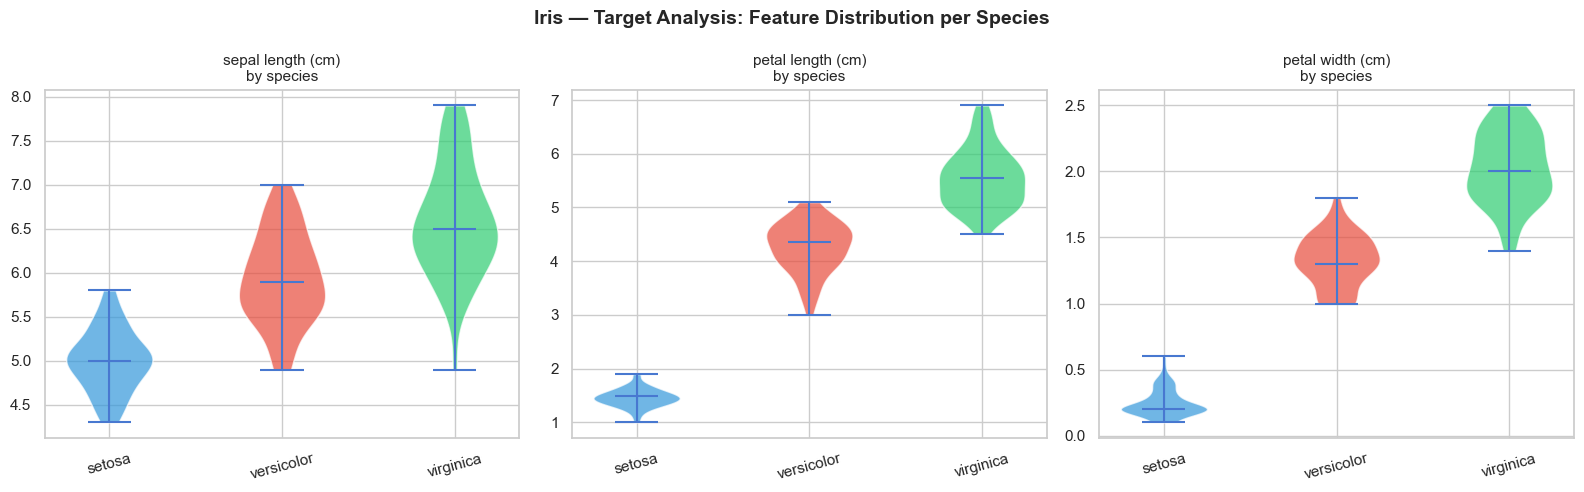

Separability analysis:
  sepal length (cm)         separation ratio=1.91   Good
  sepal width (cm)          separation ratio=1.51   Good
  petal length (cm)         separation ratio=2.32   Excellent
  petal width (cm)          separation ratio=2.34   Excellent


In [26]:
# =============================================
# EXAMPLE 5C — Iris: Multi-class Target Analysis
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Violin plots — each feature by species
plot_pairs = [
    ('sepal length (cm)', 'sepal width (cm)'),
    ('petal length (cm)', 'petal width (cm)'),
]

# Box plots per feature
for i, feat in enumerate(['sepal length (cm)', 'petal length (cm)', 'petal width (cm)']):
    data_by_species = [iris[iris['species']==sp][feat].values
                       for sp in ['setosa', 'versicolor', 'virginica']]
    vp = axes[i].violinplot(data_by_species, positions=[1, 2, 3], showmedians=True)
    for j, pc in enumerate(vp['bodies']):
        pc.set_facecolor(list(species_colors.values())[j])
        pc.set_alpha(0.7)
    axes[i].set_xticks([1, 2, 3])
    axes[i].set_xticklabels(['setosa', 'versicolor', 'virginica'], rotation=15)
    axes[i].set_title(f'{feat}\nby species', fontsize=11)

plt.suptitle('Iris — Target Analysis: Feature Distribution per Species', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Separability analysis:')
for feat in feature_cols:
    group_means = iris.groupby('species')[feat].mean()
    spread = group_means.max() - group_means.min()
    overall_std = iris[feat].std()
    sep_ratio = spread / overall_std
    tag = ' Excellent' if sep_ratio > 2 else ' Good' if sep_ratio > 1 else ' Weak'
    print(f'  {feat:<25} separation ratio={sep_ratio:.2f}  {tag}')

---
#  Part 6 — Domain Context Interpretation

Raw numbers alone don't tell the full story. **Domain knowledge** turns observations into insights.

###  Why it matters:
> A model trained without domain understanding can be statistically valid but practically useless. Domain context tells you *which features to trust*, *which to create*, and *which to be skeptical of*.

In [27]:
# =============================================
# EXAMPLE 6A — Titanic: Domain Context
# =============================================

print('=' * 60)
print('TITANIC — Domain Context Analysis')
print('=' * 60)

# "Women and children first" policy
print('\n[1] "Women and children first" policy:')
wc_survival = titanic.groupby('who')['survived'].mean()
for who, rate in wc_survival.items():
    print(f'   {who:<8} survival rate = {rate:.2%}')

# Wealth & access (pclass, fare)
print('\n[2] Wealth = Better deck position + closer lifeboats:')
class_fare = titanic.groupby('pclass').agg({'fare':'mean', 'survived':'mean'})
display(class_fare.round(3))

# Embarkation — proxy for socioeconomics
print('\n[3] Embarkation point as socioeconomic proxy:')
emb_stats = titanic.groupby('embarked').agg(
    survival_rate=('survived', 'mean'),
    avg_fare=('fare', 'mean'),
    count=('survived', 'count')
)
display(emb_stats.round(3))
print('   → Cherbourg (C) had wealthier passengers; higher survival')

# Family context
print('\n[4] Family size — safety in numbers vs chaos:')
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
fam_surv = titanic.groupby('family_size')['survived'].mean()
print(fam_surv.round(3).to_string())
print('   → Solo travelers (size=1) had lower survival')
print('   → Very large families also suffered (hard to coordinate evacuation)')

TITANIC — Domain Context Analysis

[1] "Women and children first" policy:
   child    survival rate = 59.04%
   man      survival rate = 16.39%
   woman    survival rate = 75.65%

[2] Wealth = Better deck position + closer lifeboats:


,fare,survived
pclass,,
1,84.155,0.630
2,20.662,0.473
3,13.676,0.242



[3] Embarkation point as socioeconomic proxy:


,survival_rate,avg_fare,count
embarked,,,
C,0.554,59.954,168
Q,0.390,13.276,77
S,0.337,27.080,644


   → Cherbourg (C) had wealthier passengers; higher survival

[4] Family size — safety in numbers vs chaos:
family_size
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
   → Solo travelers (size=1) had lower survival
   → Very large families also suffered (hard to coordinate evacuation)


In [28]:
# =============================================
# EXAMPLE 6B — Tips: Domain Context
# =============================================
print('=' * 60)
print('TIPS — Domain Context Analysis')
print('=' * 60)

print('\n[1] Social norms around tipping in the US (~15-20%):')
bins = [0, 10, 15, 20, 25, 100]
labels = ['<10%', '10-15%', '15-20%', '20-25%', '>25%']
tips['tip_range'] = pd.cut(tips['tip_pct'], bins=bins, labels=labels)
print(tips['tip_range'].value_counts().sort_index())

print('\n[2] Weekend effect (higher bills, higher tips):')
tips['is_weekend'] = tips['day'].isin(['Sat', 'Sun']).astype(int)
weekend_stats = tips.groupby('is_weekend').agg(
    avg_bill=('total_bill','mean'),
    avg_tip_pct=('tip_pct','mean'),
    count=('tip','count')
)
weekend_stats.index = ['Weekday','Weekend']
display(weekend_stats.round(2))

print('\n[3] Party size affects tipping psychology:')
print('   (Large groups often split bills, individual tip amount decreases)')
print(tips.groupby('size')['tip_pct'].mean().round(2))

TIPS — Domain Context Analysis

[1] Social norms around tipping in the US (~15-20%):
tip_range
<10%      27
10-15%    82
15-20%    96
20-25%    29
>25%      10
Name: count, dtype: int64

[2] Weekend effect (higher bills, higher tips):


,avg_bill,avg_tip_pct,count
Weekday,17.56,16.33,81
Weekend,20.89,15.96,163



[3] Party size affects tipping psychology:
   (Large groups often split bills, individual tip amount decreases)
size
1    21.73
2    16.57
3    15.22
4    14.59
5    14.15
6    15.62
Name: tip_pct, dtype: float64


In [29]:
# =============================================
# EXAMPLE 6C — Iris: Domain Context
# =============================================
print('=' * 60)
print('IRIS — Domain Context Analysis')
print('=' * 60)

print('\n[1] Botanical context: sepal vs petal')
print('   Sepals: outer protective leaf-like structures')
print('   Petals: inner colorful flower structures')
print('   → Petals vary more by species (adaptive, evolutionary pressure)')

print('\n[2] Mean values per species (cm):')
species_means = iris.groupby('species')[feature_cols].mean()
display(species_means.round(2))

print('\n[3] Setosa is linearly separable from the others:')
print('   petal length < 2.5 cm → almost certainly setosa')
petal_lt_25 = iris[iris['petal length (cm)'] < 2.5]['species'].value_counts()
print(f'   Flowers with petal_length < 2.5: {dict(petal_lt_25)}')

print('\n[4] Feature ratio as domain feature:')
iris['petal_ratio'] = iris['petal length (cm)'] / iris['petal width (cm)']
print(iris.groupby('species')['petal_ratio'].mean().round(2))
print('   → petal_ratio separates setosa from versicolor/virginica clearly')

IRIS — Domain Context Analysis

[1] Botanical context: sepal vs petal
   Sepals: outer protective leaf-like structures
   Petals: inner colorful flower structures
   → Petals vary more by species (adaptive, evolutionary pressure)

[2] Mean values per species (cm):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03



[3] Setosa is linearly separable from the others:
   petal length < 2.5 cm → almost certainly setosa
   Flowers with petal_length < 2.5: {'setosa': np.int64(50), 'versicolor': np.int64(0), 'virginica': np.int64(0)}

[4] Feature ratio as domain feature:
species
setosa        6.91
versicolor    3.24
virginica     2.78
Name: petal_ratio, dtype: float64
   → petal_ratio separates setosa from versicolor/virginica clearly


---
#  Summary — EDA Checklist

Use this checklist every time you start a new dataset:

| # | Task | Tools | What to look for |
|---|------|-------|------------------|
| 1 | Check shape & types | `.shape`, `.dtypes`, `.nunique()` | Unexpected types, cardinality |
| 2 | Basic statistics | `.describe()` | Range, mean/median gaps (skew) |
| 3 | Missing values | `.isnull().sum()`, heatmap | % missing, is it informative? |
| 4 | Distribution shapes | histograms, KDE, box plots | Skew, bimodality, outliers |
| 5 | Categorical distributions | bar charts, value_counts | Class imbalance, rare categories |
| 6 | Correlations | heatmap, pairplot | Redundancy, multicollinearity |
| 7 | Target variable | counts, KDE by class | Imbalance, separability |
| 8 | Feature vs target | grouped means, box/violin plots | Predictive strength |
| 9 | Domain interpretation | crosstabs, ratios, binning | Hidden patterns, engineerable features |

---

### Key Principles:

- **Always stratify by the target** — a feature may look uninformative overall but be highly discriminative per class
- **Missing data is data** — the fact that something is missing often tells you something
- **Domain knowledge beats statistics** — a feature with r=0.2 but clear causal logic is often more reliable than r=0.6 spurious correlation
- **Visualize before you model** — distributions you see in charts guide every preprocessing decision that follows